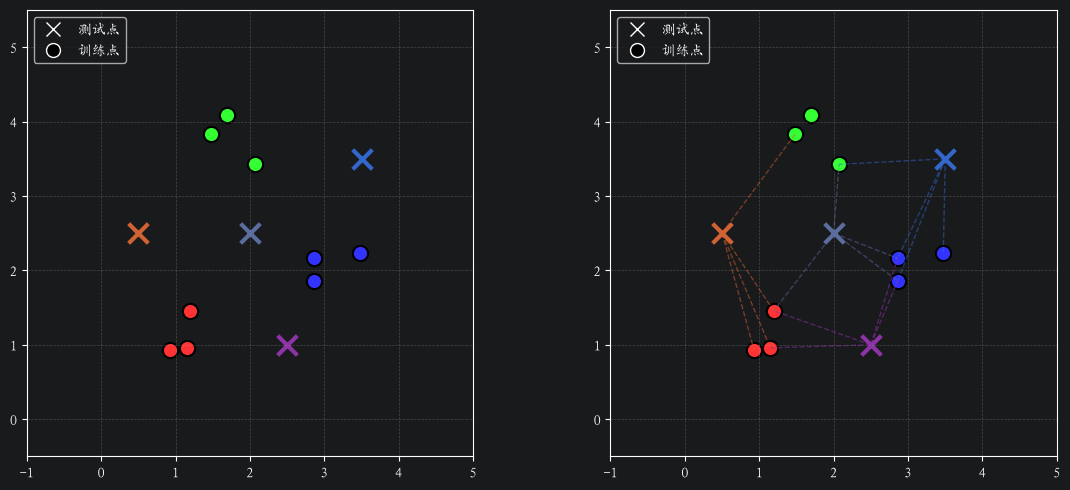

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams['font.sans-serif'] = ['Kai']
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 生成训练数据
# ============================================
clusters = [
    {'center': (1, 1), 'color': (1.0, 0.2, 0.2)},  # 红色
    {'center': (3, 2), 'color': (0.2, 0.2, 1.0)},  # 蓝色
    {'center': (2, 4), 'color': (0.2, 1.0, 0.2)}   # 绿色
]
def rgb2hex(rgb: tuple[float, float, float]) -> str:
    """
    (r,g,b) 每个分量取值 0.0 ~ 1.0
    返回 #RRGGBB
    """
    r = int(round(np.clip(rgb[0], 0, 1) * 255))
    g = int(round(np.clip(rgb[1], 0, 1) * 255))
    b = int(round(np.clip(rgb[2], 0, 1) * 255))
    return f"#{r:02X}{g:02X}{b:02X}"

X_train = []
y_train = []
np.random.seed(42)
for cluster in clusters:
    center = cluster['center']
    color = cluster['color']
    points = np.random.randn(3, 2) * 0.3 + center
    X_train.extend(points)
    y_train.extend([color] * 3)

X_train = np.array(X_train)
y_train = np.array(y_train)

# ============================================
# 训练 KNN 回归
# ============================================
knn = KNeighborsRegressor(n_neighbors=4, weights='distance')
knn.fit(X_train, y_train)

# ============================================
# 测试数据：4个点
# ============================================
X_test = np.array([[0.5, 2.5], [2.5, 1], [3.5, 3.5], [2, 2.5]])
y_pred = knn.predict(X_test)

# ============================================
# 绘图
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(-1, 5)
    ax.set_ylim(-0.5, 5.5)
    ax.set_aspect('equal')

# 左图
for i in range(len(X_train)):
    ax1.scatter(X_train[i, 0], X_train[i, 1],
               c=rgb2hex(y_train[i]), s=120, marker='o',
               edgecolors='black', linewidth=1.5)

for i in range(len(X_test)):
    ax1.scatter(X_test[i, 0], X_test[i, 1],
               c=rgb2hex(y_pred[i]), s=200, marker='x',
               linewidth=3)

# 右图
for i in range(len(X_train)):
    ax2.scatter(X_train[i, 0], X_train[i, 1],
               c=rgb2hex(y_train[i]), s=120, marker='o',
               edgecolors='black', linewidth=1.5)

for i in range(len(X_test)):
    # 绘制测试点
    ax2.scatter(X_test[i, 0], X_test[i, 1],
               c=rgb2hex(y_pred[i]), s=200, marker='x',
               linewidth=3)

    # 绘制到最近2个邻居的连线
    distances, indices = knn.kneighbors([X_test[i]])
    for idx in indices[0]:
        ax2.plot([X_test[i, 0], X_train[idx, 0]],
                [X_test[i, 1], X_train[idx, 1]],
                rgb2hex(y_pred[i]), linestyle='--', linewidth=1, alpha=0.5)

# 添加图例（左图）
legend_elements = [
    Line2D([0], [0], marker='x', color='w', markerfacecolor='black',
           markersize=10, linewidth=0, label='测试点'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markersize=10, linewidth=0, label='训练点')
]
ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()